In [1]:
# torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.transforms import transforms
import torch.optim as optim
# utils
import os
from glob import glob
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix

In [2]:
import torch
from glob import glob
import os
import random
from collections import Counter

# Global variables
device = "cuda" if torch.cuda.is_available() else "cpu"
dataset_path = r"Indian Medicinal Leaves Image Datasets\Medicinal plant dataset" 
image_size = (224, 224)

# Get all subdirectory paths in the dataset path
subfolders = [f.path for f in os.scandir(dataset_path) if f.is_dir()]

# Initialize lists to store image paths and labels
image_paths = []
labels = []

# Iterate through each subdirectory
for folder in subfolders:
    # Get all image paths in the current folder
    image_files = glob(os.path.join(folder, "*.jpg"))
    # Assign label based on folder name (e.g., "Normal" or "Stroke")
    label = os.path.basename(folder)
    # Extend the image paths list and labels list
    image_paths.extend(image_files)
    labels.extend([label] * len(image_files))

# Combine the paths and labels into a list of tuples for shuffling
data = list(zip(image_paths, labels))
random.shuffle(data)

# Unzip the data
image_paths, labels = zip(*data)

# Get unique classes and their counts
class_counts = Counter(labels)
classes = list(class_counts.keys())
num_classes = len(classes)

# Print the list of classes and their counts
print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")
print("Class counts:")
for class_name, count in class_counts.items():
    print(f"  {class_name}: {count} images")

# Split the data into training and testing sets
train_ratio = 0.8  # 80% for training, 20% for testing
train_size = int(train_ratio * len(image_paths))
train_paths = image_paths[:train_size]
test_paths = image_paths[train_size:]
train_labels = labels[:train_size]
test_labels = labels[train_size:]

# Check device
print(device)

# Print the number of images in each set for verification
print(f"Total images: {len(image_paths)}")
print(f"Training set size: {len(train_paths)}")
print(f"Testing set size: {len(test_paths)}")


Classes: ['Ekka', 'Geranium', 'Mint', 'Nithyapushpa', 'Pepper', 'Pomegranate', 'Hibiscus', 'Pappaya', 'Curry_Leaf', 'Nooni', 'Gauva', 'Insulin', 'Sapota', 'Amla', 'Arali', 'Castor', 'Raktachandini', 'Neem', 'Jasmine', 'Ashwagandha', 'Rose', 'Doddapatre', 'Nagadali', 'Betel', 'Betel_Nut', 'Brahmi', 'Lemon', 'Aloevera', 'Ashoka', 'Avacado', 'Mango', 'Basale', 'Ganike', 'Lemon_grass', 'Henna', 'Tulasi', 'Wood_sorel', 'Amruta_Balli', 'Honge', 'Bamboo']
Number of classes: 40
Class counts:
  Ekka: 146 images
  Geranium: 146 images
  Mint: 153 images
  Nithyapushpa: 146 images
  Pepper: 146 images
  Pomegranate: 146 images
  Hibiscus: 165 images
  Pappaya: 146 images
  Curry_Leaf: 146 images
  Nooni: 146 images
  Gauva: 146 images
  Insulin: 146 images
  Sapota: 146 images
  Amla: 146 images
  Arali: 146 images
  Castor: 160 images
  Raktachandini: 146 images
  Neem: 146 images
  Jasmine: 187 images
  Ashwagandha: 146 images
  Rose: 168 images
  Doddapatre: 146 images
  Nagadali: 152 images
 

In [3]:
# data augmentation
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [4]:
# custom dataset class
class dataset(Dataset):
    def __init__(self,paths,transform=None):
        self.paths = paths
        self.transform = transform
        self.labels = [self.get_label(path) for path in self.paths]
        self.labels_to_index = {label:index for index,label in enumerate(list(set(self.labels)))}
    
    def __getitem__(self,index):
        img_path = self.paths[index]
        img = Image.open(img_path).convert('RGB') 
        label = self.labels[index]
        label_index = self.labels_to_index[label]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label_index,label
    
    
    def __len__(self):
        return len(self.paths)
    
    
    def get_label(self, path):
        return os.path.basename(os.path.dirname(path))

In [5]:
train_dataset = dataset(train_paths, transform=train_transform)
test_dataset = dataset(test_paths, transform=test_transform)
val_dataset, test_dataset = train_test_split(test_dataset,test_size=0.5)

In [6]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# Define the VGG16 model
class VGG16Model(nn.Module):
    def __init__(self, num_classes=40):  # Change num_classes based on your dataset
        super(VGG16Model, self).__init__()
        
        # Load a pre-trained VGG16 model
        self.vgg16 = models.vgg16(pretrained=True)
        
        # Freeze the parameters of the pre-trained layers
        for param in self.vgg16.parameters():
            param.requires_grad = False
        
        # Modify the classifier part of the VGG16 model for your dataset
        self.vgg16.classifier[6] = nn.Linear(self.vgg16.classifier[6].in_features, num_classes)
    
    def forward(self, x):
        return self.vgg16(x)

# Instantiate the model
model = VGG16Model(num_classes=40)  # Change num_classes if necessary for your dataset

# Move the model to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    best_model_wts = model.state_dict()
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Train phase
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0
        for data in train_loader:
            # Assuming your DataLoader returns more than two values, e.g., (inputs, labels, extra)
            inputs, labels = data[0], data[1]  # Adjust unpacking if necessary

            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # Backward
            loss.backward()
            optimizer.step()

            # Statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = running_corrects.double() / total
        print(f'Training Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        total = 0
        with torch.no_grad():
            for data in val_loader:
                # Assuming your DataLoader returns more than two values, e.g., (inputs, labels, extra)
                inputs, labels = data[0], data[1]  # Adjust unpacking if necessary

                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        val_loss = val_loss / total
        val_acc = val_corrects.double() / total
        print(f'Validation Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

        # Deep copy the model if it has the best accuracy
        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = model.state_dict()

    print(f'Best validation accuracy: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model

# Train the model
model = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)


C:\Users\0945\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\0945\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10
----------
Training Loss: 1.9282 Acc: 0.4981
Validation Loss: 2.1747 Acc: 0.5943
Epoch 2/10
----------
Training Loss: 1.1221 Acc: 0.6754
Validation Loss: 2.2183 Acc: 0.6145
Epoch 3/10
----------
Training Loss: 0.9518 Acc: 0.7189
Validation Loss: 2.2790 Acc: 0.6431
Epoch 4/10
----------
Training Loss: 0.8781 Acc: 0.7344
Validation Loss: 2.3483 Acc: 0.6566
Epoch 5/10
----------
Training Loss: 0.8065 Acc: 0.7506
Validation Loss: 2.4591 Acc: 0.6684
Epoch 6/10
----------
Training Loss: 0.7495 Acc: 0.7717
Validation Loss: 2.4349 Acc: 0.6953
Epoch 7/10
----------
Training Loss: 0.7560 Acc: 0.7710
Validation Loss: 2.5699 Acc: 0.6751
Epoch 8/10
----------
Training Loss: 0.7174 Acc: 0.7752
Validation Loss: 2.5422 Acc: 0.6919
Epoch 9/10
----------
Training Loss: 0.7068 Acc: 0.7780
Validation Loss: 2.6085 Acc: 0.6919
Epoch 10/10
----------
Training Loss: 0.6661 Acc: 0.7958
Validation Loss: 2.7268 Acc: 0.6616
Best validation accuracy: 0.6953


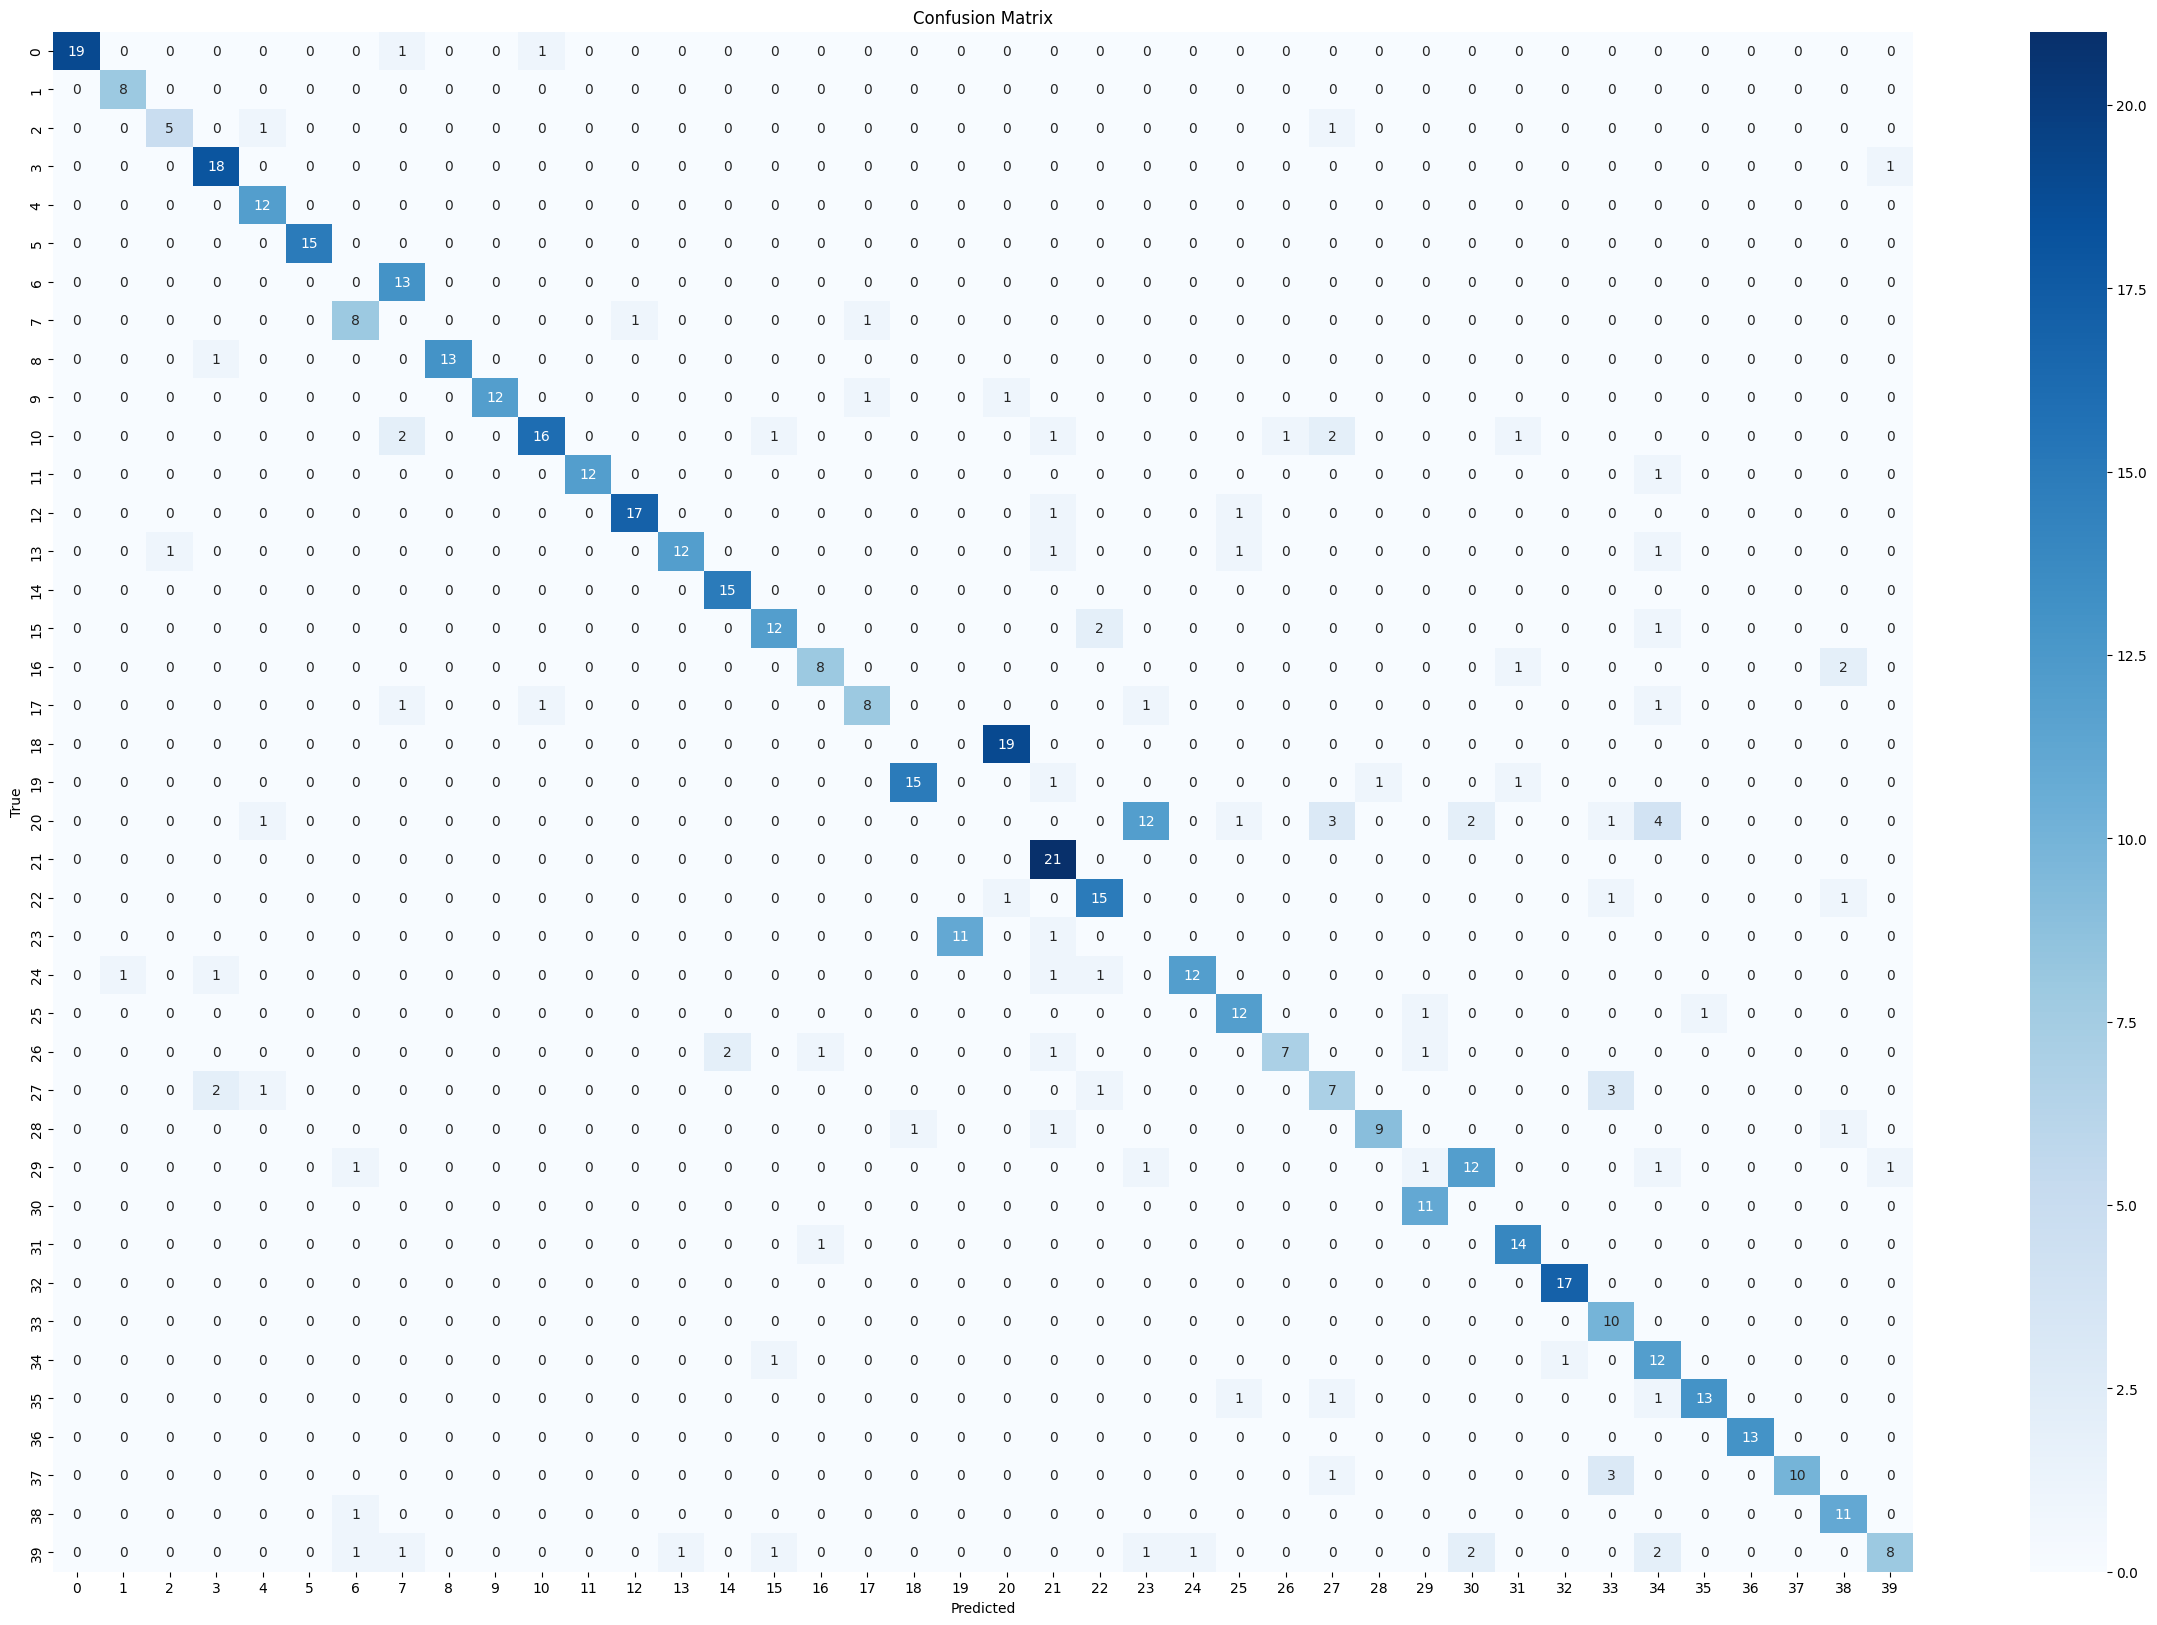

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        21
           1       0.89      1.00      0.94         8
           2       0.83      0.71      0.77         7
           3       0.82      0.95      0.88        19
           4       0.80      1.00      0.89        12
           5       1.00      1.00      1.00        15
           6       0.00      0.00      0.00        13
           7       0.00      0.00      0.00        10
           8       1.00      0.93      0.96        14
           9       1.00      0.86      0.92        14
          10       0.89      0.67      0.76        24
          11       1.00      0.92      0.96        13
          12       0.94      0.89      0.92        19
          13       0.92      0.75      0.83        16
          14       0.88      1.00      0.94        15
          15       0.80      0.80      0.80        15
          16       0.80      0.73      0.76        11
    

In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Function to evaluate the model and compute confusion matrix and classification report
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data[0], data[1]  # Adjust unpacking if necessary
            inputs, labels = inputs.to(device), labels.to(device)

            # Get predictions
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate confusion matrix and classification report
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds, target_names=[str(i) for i in range(40)])  # Adjust target_names for your classes

    # Display confusion matrix
    plt.figure(figsize=(30, 20))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(40)], yticklabels=[str(i) for i in range(40)])
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    # Print classification report
    print('Classification Report:')
    print(cr)

# Assuming you have a test_loader with your test dataset
evaluate_model(model, test_loader)
